In [1]:
%run ../../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [2]:
from src.data.dataset_builder import DatasetBuilder
from src.features.feature_extractor import FeatureExtractor
from src.data.dataset import KidneyStoneDataset
from src.features.lbp import LocalBinaryPattern
from src.features.hsv import HSV_extractor

from src.pipelines.xgboost_pipeline import XGBoostExperiment



In [3]:
builder = DatasetBuilder(root_path= DATASET_PATH_XGBOOST)
lbp = LocalBinaryPattern(numPoints=NUMPOINTS, radius=RADIUS)
hsv = HSV_extractor(n_bins=N_BINS)
extractor = FeatureExtractor(hsv, lbp)

In [4]:
results= []
task_name = "multiclase"
task_config = TASKS[task_name]
df = builder.build(classes=task_config["classes"])
xgboost_model= XGBoostExperiment(df, extractor, Case.IMAGE)


  Features shape: (397, 40)
  Distribución: {0: 192, 1: 24, 2: 115, 3: 35, 4: 31}


In [5]:
config = {
"name": f"xgboost_images_{task_name}",
"output_dir": f"experiments/xgboost/xgboost_images/xgboost_{task_name}",
"class_names": task_config["class_names"],
}

result= xgboost_model.search_hyperparameters(config)



BÚSQUEDA HP: xgboost_images_multiclase
  use_sample_weight = False


  0%|          | 0/100 [00:00<?, ?it/s]

  CV score: 0.5860
  Best params: {'max_depth': 7, 'min_child_weight': 4, 'n_estimators': 101, 'learning_rate': 0.09064492438032919, 'subsample': 0.6653855901601993, 'colsample_bytree': 0.8568675873350964}


In [5]:

import json

with open("experiments/xgboost/xgboost_images/xgboost_multiclase/best_params.json") as f:
          best_params = json.load(f)


EVALUACIÓN CV: xgboost_images_multiclase (5 folds)
  use_augmentation = False

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.7012 ± 0.0426
  auc_weighted: 0.8767 ± 0.0378
  f1_weighted: 0.6909 ± 0.0359
  precision_weighted: 0.7119 ± 0.0374
  recall_weighted: 0.7012 ± 0.0426


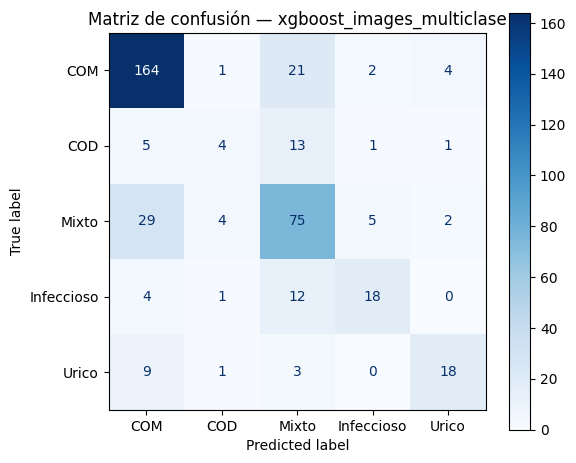

In [7]:

# evaluation_result= xgboost_model.evaluate_cv(config, result["best_params"])
evaluation_result= xgboost_model.evaluate_cv(config, best_params)

results.append(evaluation_result)

BALANCEAR LOS DATOS


EVALUACIÓN CV: xgboost_images_multiclase_sample_weight (5 folds)
  use_augmentation = False
  Fold 1: accuracy=0.6883 | precision_weighted=0.7188 | recall_weighted=0.6883 | f1_weighted=0.6927 | auc_weighted=0.8826
  Fold 2: accuracy=0.7444 | precision_weighted=0.7403 | recall_weighted=0.7444 | f1_weighted=0.7378 | auc_weighted=0.9053
  Fold 3: accuracy=0.7468 | precision_weighted=0.7401 | recall_weighted=0.7468 | f1_weighted=0.7274 | auc_weighted=0.9329
  Fold 4: accuracy=0.5972 | precision_weighted=0.6106 | recall_weighted=0.5972 | f1_weighted=0.5960 | auc_weighted=0.8427
  Fold 5: accuracy=0.5823 | precision_weighted=0.6135 | recall_weighted=0.5823 | f1_weighted=0.5920 | auc_weighted=0.8261

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.6718 ± 0.0704
  auc_weighted: 0.8779 ± 0.0393
  f1_weighted: 0.6692 ± 0.0632
  precision_weighted: 0.6847 ± 0.0598
  recall_weighted: 0.6718 ± 0.0704


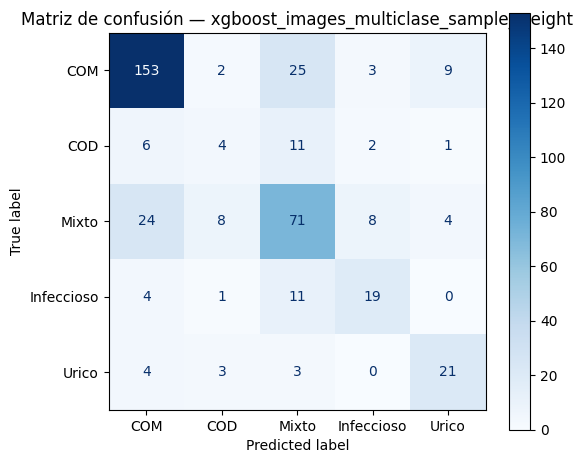

In [6]:
suffix= "sample_weight"
config_aug = {
"name": f"xgboost_images_{task_name}_{suffix}",
"output_dir": f"experiments/xgboost/xgboost_images/xgboost_{task_name}_{suffix}",
"class_names": task_config["class_names"],
    
}
evaluation_result= xgboost_model.evaluate_cv(config_aug, show_fold_metrics= True, best_params= best_params, use_sample_weight=True, use_augmentation= False)

# evaluation_result= xgboost_model.evaluate_cv(config_aug, show_fold_metrics= True, best_params= result["best_params"], use_sample_weight=True, use_augmentation= False)
results.append(evaluation_result)


EVALUACIÓN CV: xgboost_images_multiclase_with_augmentation (5 folds)
  use_augmentation = True
  Fold 1: accuracy=0.7013 | precision_weighted=0.7214 | recall_weighted=0.7013 | f1_weighted=0.7028 | auc_weighted=0.8937
  Fold 2: accuracy=0.7333 | precision_weighted=0.7319 | recall_weighted=0.7333 | f1_weighted=0.7265 | auc_weighted=0.8930
  Fold 3: accuracy=0.7215 | precision_weighted=0.6995 | recall_weighted=0.7215 | f1_weighted=0.7023 | auc_weighted=0.9305
  Fold 4: accuracy=0.5833 | precision_weighted=0.5926 | recall_weighted=0.5833 | f1_weighted=0.5849 | auc_weighted=0.8215
  Fold 5: accuracy=0.6456 | precision_weighted=0.6617 | recall_weighted=0.6456 | f1_weighted=0.6489 | auc_weighted=0.8351

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.6770 ± 0.0557
  auc_weighted: 0.8748 ± 0.0405
  f1_weighted: 0.6731 ± 0.0509
  precision_weighted: 0.6814 ± 0.0505
  recall_weighted: 0.6770 ± 0.0557


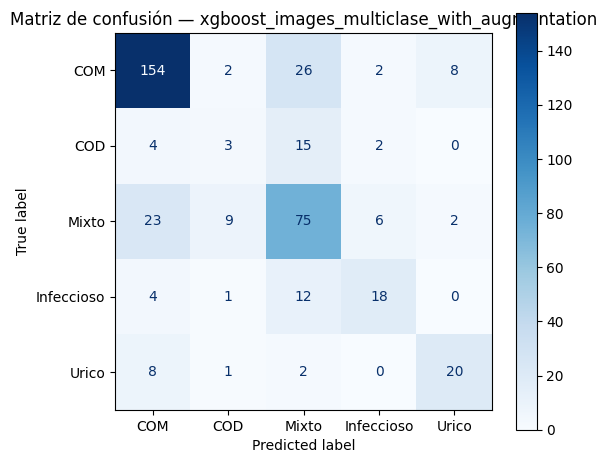

In [6]:
suffix= "with_augmentation"
config_aug = {
"name": f"xgboost_images_{task_name}_{suffix}",
"output_dir": f"experiments/xgboost/xgboost_images/xgboost_{task_name}_{suffix}",
"class_names": task_config["class_names"],
    
}
import json

with open("experiments/xgboost/xgboost_images/xgboost_multiclase/best_params.json") as f:
          best_params = json.load(f)
evaluation_result= xgboost_model.evaluate_cv(config_aug, show_fold_metrics= True, best_params= best_params, use_sample_weight=False, use_augmentation= True)

# evaluation_result= xgboost_model.evaluate_cv(config_aug, show_fold_metrics= True, best_params= result["best_params"], use_sample_weight=False, use_augmentation= True)


2. Usar SMOTE


EVALUACIÓN CV: xgboost_images_multiclase_using_smote (5 folds)
  use_augmentation = False
  Fold 1: accuracy=0.7013 | precision_weighted=0.7267 | recall_weighted=0.7013 | f1_weighted=0.7112 | auc_weighted=0.8666
  Fold 2: accuracy=0.7111 | precision_weighted=0.7175 | recall_weighted=0.7111 | f1_weighted=0.7092 | auc_weighted=0.9004
  Fold 3: accuracy=0.7468 | precision_weighted=0.7382 | recall_weighted=0.7468 | f1_weighted=0.7310 | auc_weighted=0.9180
  Fold 4: accuracy=0.6528 | precision_weighted=0.6764 | recall_weighted=0.6528 | f1_weighted=0.6565 | auc_weighted=0.8387
  Fold 5: accuracy=0.5949 | precision_weighted=0.6382 | recall_weighted=0.5949 | f1_weighted=0.6032 | auc_weighted=0.8252

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.6814 ± 0.0526
  auc_weighted: 0.8698 ± 0.0353
  f1_weighted: 0.6822 ± 0.0466
  precision_weighted: 0.6994 ± 0.0370
  recall_weighted: 0.6814 ± 0.0526


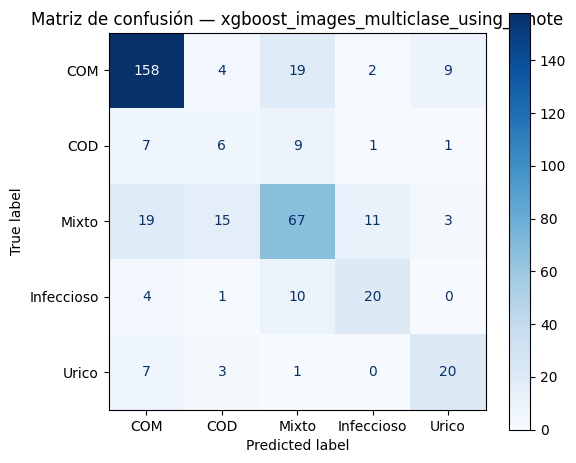

In [6]:
suffix= "using_smote"
config_s = {
"name": f"xgboost_images_{task_name}_{suffix}",
"output_dir": f"experiments/xgboost/xgboost_images/xgboost_{task_name}_{suffix}",
"class_names": task_config["class_names"],
}
evaluation_result= xgboost_model.evaluate_cv(config_s, show_fold_metrics= True, best_params= best_params, use_sample_weight=False, use_augmentation= False, apply_smote= True)

# evaluation_result= xgboost_model.evaluate_cv(config_s, show_fold_metrics= True, best_params= result["best_params"], use_sample_weight=False, use_augmentation= False, apply_smote= True)
results.append(evaluation_result)


EVALUACIÓN CV: xgboost_images_multiclase_sample_weight_and_smote (5 folds)
  use_augmentation = False
  Fold 1: accuracy=0.7013 | precision_weighted=0.7267 | recall_weighted=0.7013 | f1_weighted=0.7112 | auc_weighted=0.8666
  Fold 2: accuracy=0.7111 | precision_weighted=0.7175 | recall_weighted=0.7111 | f1_weighted=0.7092 | auc_weighted=0.9004
  Fold 3: accuracy=0.7468 | precision_weighted=0.7382 | recall_weighted=0.7468 | f1_weighted=0.7310 | auc_weighted=0.9180
  Fold 4: accuracy=0.6528 | precision_weighted=0.6764 | recall_weighted=0.6528 | f1_weighted=0.6565 | auc_weighted=0.8387
  Fold 5: accuracy=0.5949 | precision_weighted=0.6382 | recall_weighted=0.5949 | f1_weighted=0.6032 | auc_weighted=0.8252

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.6814 ± 0.0526
  auc_weighted: 0.8698 ± 0.0353
  f1_weighted: 0.6822 ± 0.0466
  precision_weighted: 0.6994 ± 0.0370
  recall_weighted: 0.6814 ± 0.0526


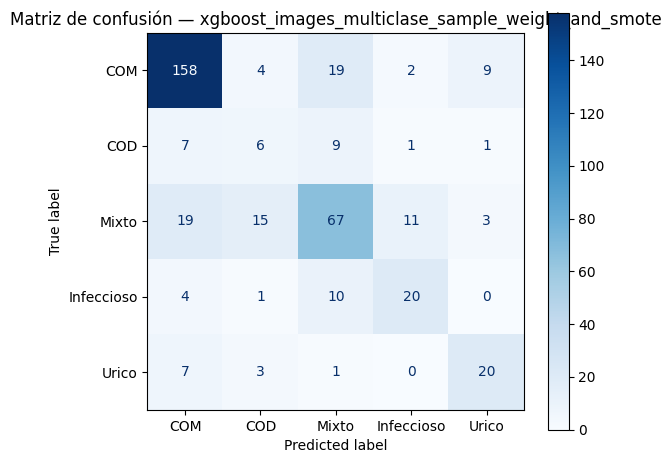

In [9]:
suffix= "sample_weight_and_smote"
config_s = {
"name": f"xgboost_images_{task_name}_{suffix}",
"output_dir": f"experiments/xgboost/xgboost_images/xgboost_{task_name}_{suffix}",
"class_names": task_config["class_names"],
}
aug_sample_weight= xgboost_model.evaluate_cv(config_s, show_fold_metrics= True, best_params= best_params, use_sample_weight=True, use_augmentation= False, apply_smote= True)

# aug_sample_weight= xgboost_model.evaluate_cv(config_s, show_fold_metrics= True, best_params= result["best_params"], use_sample_weight=True, use_augmentation= False, apply_smote= True)
results.append(aug_sample_weight)


EVALUACIÓN CV: xgboost_images_multiclase_sample_weight_and_augmentation (5 folds)
  use_augmentation = True
  Fold 1: accuracy=0.6494 | precision_weighted=0.7087 | recall_weighted=0.6494 | f1_weighted=0.6758 | auc_weighted=0.8574
  Fold 2: accuracy=0.7222 | precision_weighted=0.6848 | recall_weighted=0.7222 | f1_weighted=0.7022 | auc_weighted=0.8982
  Fold 3: accuracy=0.7595 | precision_weighted=0.7559 | recall_weighted=0.7595 | f1_weighted=0.7445 | auc_weighted=0.9265
  Fold 4: accuracy=0.6389 | precision_weighted=0.6613 | recall_weighted=0.6389 | f1_weighted=0.6405 | auc_weighted=0.8313
  Fold 5: accuracy=0.6076 | precision_weighted=0.6466 | recall_weighted=0.6076 | f1_weighted=0.6216 | auc_weighted=0.8303

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.6755 ± 0.0563
  auc_weighted: 0.8687 ± 0.0380
  f1_weighted: 0.6769 ± 0.0438
  precision_weighted: 0.6915 ± 0.0385
  recall_weighted: 0.6755 ± 0.0563


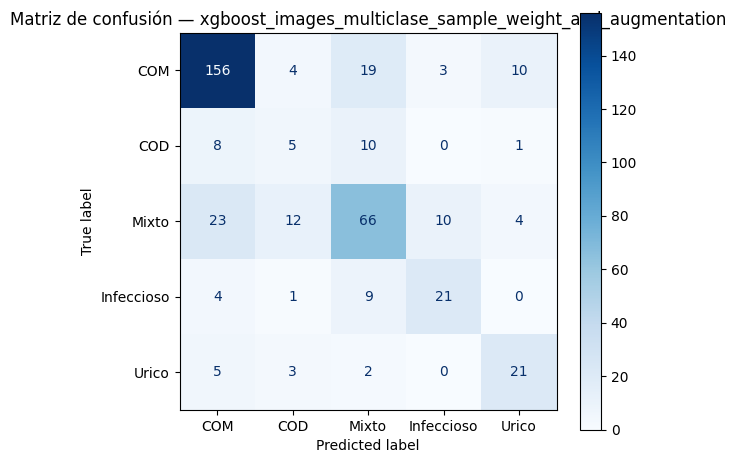

In [10]:
suffix= "sample_weight_and_augmentation"
config_s = {
"name": f"xgboost_images_{task_name}_{suffix}",
"output_dir": f"experiments/xgboost/xgboost_images/xgboost_{task_name}_{suffix}",
"class_names": task_config["class_names"],
}
sw_and_aug= xgboost_model.evaluate_cv(config_s, show_fold_metrics= True, best_params= best_params, use_sample_weight=True, use_augmentation= True, apply_smote= False)

# sw_and_aug= xgboost_model.evaluate_cv(config_s, show_fold_metrics= True, best_params= result["best_params"], use_sample_weight=True, use_augmentation= True, apply_smote= False)
results.append(sw_and_aug)